# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-21: HR RhythmMamba v2 - SNR loss

### What this notebook does
Retrains RhythmMamba (state-space / Mamba, Zou & Guo et al., AAAI 2025) with the 2026 SNR frequency loss and compares it, on one fixed subject-wise split, against the RhythmMamba v1 screen (NB_P3_10, neg-Pearson + frequency-match loss, best val HR MAE 6.83 bpm, MCD 10.49). Everything except the loss is held identical to NB_P3_10 - same architecture, optimizer (Adam, lr 1e-3, weight decay 1e-4), 30-epoch cosine schedule, augmentation and multi-clip sampling - so the change in error isolates the SNR-loss effect.

### Why this experiment
RhythmMamba won the v1 screen on raw MAE (6.83) and was best on clean DLCN, but its MCD (10.49) matched PhysNet's (10.69) - the same noisy-reference ceiling that capped every architecture. On PhysNet the SNR loss broke that ceiling (MCD 10.69 to 6.84, shared 7.31 to 5.22; NB_P3_18). The question is whether the SNR loss compresses RhythmMamba's MCD the same way, which would make the phase's best architecture also its best-generalizing one. RhythmMamba clicks late (its v1 best landed at epoch 21 of 30), so the late epochs matter here.

### Recipe and rules
- Loss = neg_pearson + LAMBDA_SNR * snr_loss (in-band SNR at the reference fundamental + first harmonic, per-sample fps, invalid-HR clips masked), each clip weighted by cardiac_sqi.
- One fixed subject-wise split (seed 42) across all four datasets.
- Training corpus = MCD + DLCN + UBFC-rPPG. PhysDrive is evaluation-only (zero-shot), consistent with NB_P3_18 where adding the in-vehicle corpus to training diverged the model.
- Checkpoint on the shared MCD+DLCN+UBFC MAE so PhysDrive's large zero-shot variance never drives selection.
- RhythmMamba runs from the official repo (zizheng-guo/RhythmMamba); its forward is forced to fp32 because the model's internal frequency-domain FFT cannot run in fp16 at non-power-of-2 sizes. No frames are rendered.

## 1. Imports & Config (+ clone RhythmMamba, install mamba-ssm)

In [1]:
import os, sys, time, random, gc, glob, importlib
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

# Clone RhythmMamba and expose it on the path.
if not os.path.exists('RhythmMamba'):
    os.system('git clone --depth 1 https://github.com/zizheng-guo/RhythmMamba')
sys.path.append('RhythmMamba')
for d in glob.glob('RhythmMamba/**/', recursive=True):
    sys.path.append(d)

# Mamba deps (compile CUDA kernels - may take several minutes).
os.system('pip install einops -q')
os.system('pip install causal-conv1d --no-build-isolation -q')
os.system('pip install mamba-ssm --no-build-isolation -q')
try:
    import mamba_ssm
    print('mamba-ssm OK:', mamba_ssm.__version__ if hasattr(mamba_ssm, '__version__') else 'imported')
except Exception as e:
    print('WARNING mamba-ssm import failed:', repr(e))
    print('-> if this persists, the screen fallback was TYrPPG/Mambaout (no SSM dependency).')

# locate the four Phase-3 datasets across Kaggle inputs (PhysDrive is held-out eval)
WANT = ['mcd_phase3.h5', 'dlcn_phase3.h5', 'ubfc_rppg_phase3.h5', 'physdrive_phase3.h5']
H5_PATHS = []
for name in WANT:
    hits = list(Path('/kaggle/input').rglob(name))
    if hits:
        H5_PATHS.append(hits[0])
print('datasets found:', [p.name for p in H5_PATHS])

TRAIN_SET = {'MCD', 'DLCN', 'UBFC-rPPG'} # PhysDrive excluded from training (held-out)
SHARED_DATASETS = {'MCD', 'DLCN', 'UBFC-rPPG'} # checkpoint metric
V1_SCREEN = {'MCD': 10.49, 'DLCN': 2.32, 'UBFC-rPPG': 4.19} # RhythmMamba v1 (NB_P3_10); shared ALL 6.83
V1_SHARED = 6.83

CLIP_LEN = 160
IMG_SIZE = 72
BATCH_SIZE = 8 # RhythmMamba is light; drop if OOM
CLIPS_PER_REC = 2
NUM_WORKERS = 2
VAL_FRAC = 0.2
SEED = 42
AUG_PROB = 0.5
SPEED_MIN, SPEED_MAX = 0.7, 2.0
SQI_FLOOR = 0.05

# RhythmMamba recipe (identical to NB_P3_10; only the loss changes in v2)
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 30
LAMBDA_SNR = 0.05
HR_LOW, HR_HIGH = 0.66, 3.0

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True
print('device:', device, '| train on:', sorted(TRAIN_SET), '| PhysDrive = held-out eval')

Cloning into 'RhythmMamba'...
Updating files: 100% (171/171), done.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 772.4/772.4 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 16.8 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.


mamba-ssm OK: 2.3.2.post1
datasets found: ['mcd_phase3.h5', 'dlcn_phase3.h5', 'ubfc_rppg_phase3.h5', 'physdrive_phase3.h5']
device: cuda | train on: ['DLCN', 'MCD', 'UBFC-rPPG'] | PhysDrive = held-out eval


## 2. Data Loader - index, one fixed subject-split

In [2]:
def build_index(h5_paths, sqi_floor=SQI_FLOOR, clip_len=CLIP_LEN):
    index = []
    for path in h5_paths:
        with h5py.File(path, 'r') as f:
            for name in f.keys():
                a = f[name].attrs
                if not bool(a.get('usable', True)):
                    continue
                if float(a.get('cardiac_sqi', 0.0)) < sqi_floor:
                    continue
                n = int(a['n_frames'])
                if n < clip_len:
                    continue
                index.append(dict(file=str(path), group=name, dataset=str(a.get('dataset', Path(path).stem)),
                                  subject=str(a.get('subject_id', name)), n_frames=n,
                                  fps=float(a.get('fps', 30.0)), sqi=float(a.get('cardiac_sqi', 0.0))))
    return index


def subject_split(index, val_frac=VAL_FRAC, seed=SEED):
    subjects = sorted({r['dataset'] + '/' + r['subject'] for r in index})
    rng = random.Random(seed); rng.shuffle(subjects)
    n_val = max(1, int(round(len(subjects) * val_frac)))
    val_subj = set(subjects[:n_val])
    tr = [r for r in index if (r['dataset'] + '/' + r['subject']) not in val_subj]
    va = [r for r in index if (r['dataset'] + '/' + r['subject']) in val_subj]
    return tr, va, val_subj


def compute_hr(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(x.size))) ** 2
    fr = np.fft.rfftfreq(x.size, 1.0 / fps)
    b = (fr >= low) & (fr <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(fr[b][int(np.argmax(p[b]))] * 60.0)


class RPPGClipDataset(Dataset):
    def __init__(self, index, clip_len=CLIP_LEN, augment=False, clips_per_rec=1,
                 aug_prob=AUG_PROB, speed_range=(SPEED_MIN, SPEED_MAX), seed=SEED):
        self.index = index; self.clip_len = clip_len; self.augment = augment
        self.clips_per_rec = clips_per_rec; self.aug_prob = aug_prob; self.speed_range = speed_range
        self._files = {}; self._rng = np.random.default_rng(seed)

    def _h5(self, path):
        h = self._files.get(path)
        if h is None:
            h = h5py.File(path, 'r'); self._files[path] = h
        return h

    def __len__(self):
        return len(self.index) * self.clips_per_rec

    def __getitem__(self, i):
        rec = self.index[i % len(self.index)]; g = self._h5(rec['file'])[rec['group']]
        n, T = rec['n_frames'], self.clip_len
        if self.augment and self._rng.random() < self.aug_prob:
            src_len = int(round(T * float(self._rng.uniform(*self.speed_range))))
            src_len = max(T, min(src_len, n))
        else:
            src_len = T
        max_start = n - src_len
        start = int(self._rng.integers(0, max_start + 1)) if (self.augment and max_start > 0) else max_start // 2
        frames_src = g['frames'][start:start + src_len].astype(np.float32)
        bvp_src = g['bvp'][start:start + src_len].astype(np.float32)
        pos = np.linspace(0, src_len - 1, T)
        frames = frames_src[np.rint(pos).astype(int)]
        bvp = np.interp(pos, np.arange(src_len), bvp_src)
        hr_bpm = compute_hr(bvp, rec['fps'])
        if self.augment and self._rng.random() < 0.5:
            frames = frames[:, :, ::-1, :]
        m = frames.mean(axis=(0, 1, 2), keepdims=True); sd = frames.std(axis=(0, 1, 2), keepdims=True) + 1e-6
        frames = np.ascontiguousarray((frames - m) / sd)
        frames = torch.from_numpy(frames).permute(3, 0, 1, 2).float()
        bvp = (bvp - bvp.mean()) / (bvp.std() + 1e-6)
        bvp = torch.from_numpy(bvp.astype(np.float32))
        return dict(frames=frames, bvp=bvp,
                    hr=torch.tensor(hr_bpm if np.isfinite(hr_bpm) else 0.0, dtype=torch.float32),
                    sqi=torch.tensor(rec['sqi'], dtype=torch.float32),
                    fps=torch.tensor(rec['fps'], dtype=torch.float32),
                    dataset=rec['dataset'])


def worker_init_fn(worker_id):
    info = torch.utils.data.get_worker_info(); ds = info.dataset
    ds._files = {}; ds._rng = np.random.default_rng(SEED + 1000 * (worker_id + 1) + int(info.seed % 100000))


def make_loader(index, augment, clips_per_rec=1):
    ds = RPPGClipDataset(index, augment=augment, clips_per_rec=clips_per_rec)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=augment, num_workers=NUM_WORKERS,
                      worker_init_fn=worker_init_fn, pin_memory=True, drop_last=augment,
                      persistent_workers=(NUM_WORKERS > 0))


index = build_index(H5_PATHS)
train_all, val_idx, val_subj = subject_split(index)   # ONE fixed split
train_idx = [r for r in train_all if r['dataset'] in TRAIN_SET]
print('usable:', len(index), 'by dataset:', dict(Counter(r['dataset'] for r in index)))
print('val (FIXED):', len(val_idx), 'by dataset:', dict(Counter(r['dataset'] for r in val_idx)))
print('train recs:', len(train_idx), 'by dataset:', dict(Counter(r['dataset'] for r in train_idx)))

usable: 2276 by dataset: {'MCD': 1191, 'DLCN': 777, 'UBFC-rPPG': 42, 'PhysDrive': 266}
val (FIXED): 475 by dataset: {'MCD': 232, 'DLCN': 168, 'UBFC-rPPG': 7, 'PhysDrive': 68}
train recs: 1603 by dataset: {'MCD': 959, 'DLCN': 609, 'UBFC-rPPG': 35}


## 3. Model - RhythmMamba (official repo)

In [3]:
# Locate + import the RhythmMamba model class (robust to repo layout / relative imports).
RhythmMambaClass = None
for modname in ['neural_methods.model.RhythmMamba', 'model.RhythmMamba', 'RhythmMamba']:
    try:
        m = importlib.import_module(modname)
        RhythmMambaClass = getattr(m, 'RhythmMamba')
        print('imported RhythmMamba from', modname)
        break
    except Exception as e:
        print('import', modname, 'failed:', repr(e))

if RhythmMambaClass is None:
    print('RhythmMamba class NOT found. Repo model .py files:')
    for pyf in glob.glob('RhythmMamba/**/*.py', recursive=True):
        try:
            if 'class RhythmMamba' in open(pyf, errors='ignore').read():
                print('   *class here*', pyf)
            else:
                print('   ', pyf)
        except Exception:
            print('   ', pyf)
    raise RuntimeError('Could not import RhythmMamba - paste this listing.')


def build_rhythmmamba():
    last = None
    for kw in [dict(), dict(frames=CLIP_LEN), dict(dim=96)]:
        try:
            return RhythmMambaClass(**kw)
        except Exception as e:
            last = e
    raise last


def rm_forward(model, x):
    '''Our clips are [B,C,T,H,W]; RhythmMamba (rPPG-Toolbox convention) expects [B,T,C,H,W].
    Forced to fp32 because RhythmMamba's internal FFT (freq-domain FFN) cannot run in fp16
    for non-power-of-2 sizes. Returns [B,T].'''
    xx = x.permute(0, 2, 1, 3, 4).contiguous().float()
    with torch.autocast('cuda', enabled=False):
        out = model(xx)
    if isinstance(out, (tuple, list)):
        out = out[0]
    if out.dim() == 3 and out.shape[-1] == 1:
        out = out.squeeze(-1)
    if out.dim() == 3 and out.shape[1] == 1:
        out = out.squeeze(1)
    return out

imported RhythmMamba from neural_methods.model.RhythmMamba


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## 4. Losses & Evaluation

In [4]:
def neg_pearson(pred, target):
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    num = (pred * target).sum(dim=1)
    den = torch.sqrt((pred ** 2).sum(dim=1) * (target ** 2).sum(dim=1) + 1e-8)
    return 1.0 - num / (den + 1e-8)


def snr_loss(pred, hr_bpm, fps, low=HR_LOW, high=HR_HIGH, delta_bpm=8.0):
    '''Negative in-band SNR (dB): power at the true fundamental (+first harmonic) vs the rest of the HR band. fp32.'''
    pred = pred.float(); pred = pred - pred.mean(dim=1, keepdim=True)
    B, T = pred.shape
    P = torch.abs(torch.fft.rfft(pred, dim=1)) ** 2
    Fn = P.shape[1]
    k = torch.arange(Fn, device=pred.device).float()
    freqs = k[None, :] * fps[:, None] / float(T)
    f0 = (hr_bpm / 60.0).clamp(min=low + 0.05, max=high - 0.05)[:, None]
    d = delta_bpm / 60.0
    band = (freqs >= low) & (freqs <= high)
    sig = (((freqs - f0).abs() <= d) | ((freqs - 2.0 * f0).abs() <= d)) & band
    noise = band & (~sig)
    sig_p = (P * sig).sum(dim=1) + 1e-8
    noise_p = (P * noise).sum(dim=1) + 1e-8
    return (-10.0 * torch.log10(sig_p / noise_p)).clamp(-30.0, 30.0)


def hr_from_bvp(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.std() < 1e-8:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(f[b][int(np.argmax(p[b]))] * 60.0)


@torch.no_grad()
def evaluate(model, loader):
    '''Returns dict with overall MAE, shared (MCD+DLCN+UBFC) MAE, per-dataset MAE, and r.'''
    model.eval(); rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = rm_forward(model, frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    df = pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])
    if len(df) == 0:
        return dict(all=1e9, shared=1e9, per={}, r=float('nan'), n=0)
    df['ae'] = (df.hr_pred - df.hr_true).abs()
    per = df.groupby('dataset')['ae'].mean().round(3).to_dict()
    shared = df[df.dataset.isin(SHARED_DATASETS)]['ae']
    return dict(all=float(df.ae.mean()),
                shared=float(shared.mean()) if len(shared) else float(df.ae.mean()),
                per=per, n=int(len(df)),
                r=float(np.corrcoef(df.hr_true, df.hr_pred)[0, 1]) if len(df) > 2 else float('nan'))

## 5. Sanity check
Verifies the RhythmMamba clone + mamba-ssm import, the model builds at ~4.92 M parameters, a batch flows through the fp32 rm_forward to a [B, CLIP_LEN] waveform, and the two loss terms return finite values. Frame tensors are checked numerically only; no frames are rendered.

In [5]:
_tl = make_loader(train_idx, augment=True, clips_per_rec=CLIPS_PER_REC)
_vl = make_loader(val_idx, augment=False, clips_per_rec=1)
print('train clips/epoch:', len(_tl.dataset), '| val clips:', len(_vl.dataset))

model = build_rhythmmamba().to(device)
print('RhythmMamba params:', round(sum(p.numel() for p in model.parameters()) / 1e6, 2), 'M')

batch = next(iter(_tl))
print('batch frames', tuple(batch['frames'].shape), '| bvp', tuple(batch['bvp'].shape))
print('frames dtype', batch['frames'].dtype, '| mean', round(float(batch['frames'].mean()), 3), '| std', round(float(batch['frames'].std()), 3))
with torch.no_grad():
    out = rm_forward(model, batch['frames'][:2].to(device))
print('model output', tuple(out.shape), '(expect [2,', CLIP_LEN, '])')
hr2 = batch['hr'][:2].to(device); fps2 = batch['fps'][:2].to(device); bvp2 = batch['bvp'][:2].to(device)
print('neg_pearson sample:', round(float(neg_pearson(out.float(), bvp2).mean()), 4))
print('snr_loss sample:', [round(float(v), 3) for v in snr_loss(out.float(), hr2, fps2)])
del model, _tl, _vl, batch, out; gc.collect(); torch.cuda.empty_cache()

train clips/epoch: 3206 | val clips: 475
RhythmMamba params: 4.92 M
batch frames (8, 3, 160, 72, 72) | bvp (8, 160)
frames dtype torch.float32 | mean -0.0 | std 1.0


/kaggle/working/RhythmMamba/neural_methods/model/RhythmMamba.py:136: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:308.)
  x = x.to(torch.float32)


model output (2, 160) (expect [2, 160 ])
neg_pearson sample: 0.9482
snr_loss sample: [9.669, 9.026]


## 6. Training
Trains RhythmMamba on MCD + DLCN + UBFC-rPPG with the SNR-loss recipe, evaluates all four datasets each epoch (PhysDrive zero-shot), and checkpoints on the shared MCD+DLCN+UBFC MAE.

In [6]:
train_loader = make_loader(train_idx, augment=True, clips_per_rec=CLIPS_PER_REC)
val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)
print('train recs', len(train_idx), 'by ds', dict(Counter(r['dataset'] for r in train_idx)), '| clips/epoch', len(train_loader.dataset))

torch.manual_seed(SEED)
model = build_rhythmmamba().to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
scaler = GradScaler('cuda')
ckpt = 'rhythmmamba_v2_best.pt'
best = 1e9; best_per = {}; best_all = None; best_epoch = -1; hist = []
for epoch in range(EPOCHS):
    model.train(); t0 = time.time()
    for batch in train_loader:
        frames = batch['frames'].to(device, non_blocking=True)
        bvp = batch['bvp'].to(device, non_blocking=True)
        sqi = batch['sqi'].to(device, non_blocking=True)
        hr = batch['hr'].to(device, non_blocking=True)
        fps = batch['fps'].to(device, non_blocking=True)
        valid = ((hr >= 40) & (hr <= 180)).float()
        opt.zero_grad(set_to_none=True)
        with autocast('cuda'):
            pred = rm_forward(model, frames)
        pred = pred.float()
        per_loss = neg_pearson(pred, bvp) + LAMBDA_SNR * (snr_loss(pred, hr, fps) * valid)
        w = sqi.clamp(min=1e-3)
        loss = (per_loss * w).sum() / w.sum()
        scaler.scale(loss).backward(); scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update()
    sched.step()
    res = evaluate(model, val_loader)
    hist.append(dict(epoch=epoch + 1, shared=res['shared'], all=res['all'], r=res['r'],
                     **{('mae_' + k): v for k, v in res['per'].items()}))
    print('ep', epoch + 1, '/', EPOCHS, '|', round(time.time() - t0), 's | shared', round(res['shared'], 2), '| all', round(res['all'], 2), '|', res['per'])
    if res['shared'] < best:
        best = res['shared']; best_per = res['per']; best_all = res['all']; best_epoch = epoch + 1
        torch.save(model.state_dict(), ckpt); print('   * new best shared', round(best, 2))
torch.save(model.state_dict(), 'rhythmmamba_v2_last.pt')
hist_df = pd.DataFrame(hist); hist_df.to_csv('history_rhythmmamba_v2.csv', index=False)
print('DONE | best shared MAE', round(best, 2), '@ep', best_epoch, '| per-dataset', best_per)
print('RhythmMamba v1 (NB_P3_10) shared MAE was', V1_SHARED)

train recs 1603 by ds {'MCD': 959, 'DLCN': 609, 'UBFC-rPPG': 35} | clips/epoch 3206
ep 1 / 30 | 497 s | shared 44.51 | all 46.6 | {'DLCN': 46.205, 'MCD': 43.744, 'PhysDrive': 59.062, 'UBFC-rPPG': 29.445}
   * new best shared 44.51
ep 2 / 30 | 475 s | shared 47.47 | all 48.7 | {'DLCN': 47.143, 'MCD': 48.251, 'PhysDrive': 56.085, 'UBFC-rPPG': 29.445}
ep 3 / 30 | 456 s | shared 47.4 | all 49.64 | {'DLCN': 46.071, 'MCD': 48.909, 'PhysDrive': 63.033, 'UBFC-rPPG': 29.445}
ep 4 / 30 | 438 s | shared 57.49 | all 58.99 | {'DLCN': 53.371, 'MCD': 61.316, 'PhysDrive': 67.996, 'UBFC-rPPG': 29.445}
ep 5 / 30 | 430 s | shared 30.94 | all 32.34 | {'DLCN': 32.344, 'MCD': 30.023, 'PhysDrive': 40.699, 'UBFC-rPPG': 27.584}
   * new best shared 30.94
ep 6 / 30 | 450 s | shared 24.41 | all 26.2 | {'DLCN': 17.21, 'MCD': 30.129, 'PhysDrive': 36.893, 'UBFC-rPPG': 7.831}
   * new best shared 24.41
ep 7 / 30 | 435 s | shared 21.16 | all 23.34 | {'DLCN': 15.402, 'MCD': 25.927, 'PhysDrive': 36.397, 'UBFC-rPPG': 1.

## 7. Comparison - RhythmMamba v1 (NB_P3_10) vs v2 SNR loss

In [7]:
order = ['MCD', 'DLCN', 'UBFC-rPPG', 'PhysDrive']
tab = []
for dname in order:
    tab.append(dict(dataset=dname, v1_NB10=V1_SCREEN.get(dname, np.nan), v2_snr=best_per.get(dname, np.nan)))
comp = pd.DataFrame(tab).set_index('dataset')
comp.loc['shared-3 (ckpt metric)'] = [V1_SHARED, best]
comp.loc['ALL (incl PhysDrive)'] = [np.nan, best_all]
comp['delta_v2_minus_v1'] = (comp['v2_snr'] - comp['v1_NB10']).round(2)
print('RhythmMamba v1 (neg-Pearson + freq) vs v2 (neg-Pearson + SNR) - HR MAE bpm; PhysDrive is zero-shot in both')
print(comp.round(2).to_string())
print('')
print('Reads:')
print('  v1_NB10 -> v2_snr on shared-3   = the SNR-loss effect on the fixed corpus')
print('  MCD row                         = whether the SNR loss cracks the noisy-reference ceiling (v1 10.49)')
print('  PhysDrive row                   = the hard in-vehicle held-out benchmark (zero-shot)')

RhythmMamba v1 (neg-Pearson + freq) vs v2 (neg-Pearson + SNR) - HR MAE bpm; PhysDrive is zero-shot in both
                        v1_NB10  v2_snr  delta_v2_minus_v1
dataset                                                   
MCD                       10.49    8.30              -2.19
DLCN                       2.32    6.56               4.24
UBFC-rPPG                  4.19    3.12              -1.07
PhysDrive                   NaN   27.30                NaN
shared-3 (ckpt metric)     6.83    7.50               0.67
ALL (incl PhysDrive)        NaN   10.33                NaN

Reads:
  v1_NB10 -> v2_snr on shared-3   = the SNR-loss effect on the fixed corpus
  MCD row                         = whether the SNR loss cracks the noisy-reference ceiling (v1 10.49)
  PhysDrive row                   = the hard in-vehicle held-out benchmark (zero-shot)


## 8. Post-training evaluation & Bland-Altman

zero-shot datasets: ['PhysDrive']
               n    MAE   RMSE   bias  LoA_low  LoA_high  Pearson_r
DLCN       168.0   6.56  17.91   0.27   -34.95     35.48       0.54
MCD        232.0   8.30  15.85  -1.32   -32.33     29.70       0.54
PhysDrive   68.0  27.30  41.09  10.75   -67.55     89.05       0.01
UBFC-rPPG    7.0   3.12   5.83  -0.02   -12.37     12.33       0.97
ALL        475.0  10.33  21.87   0.99   -41.88     43.86       0.39


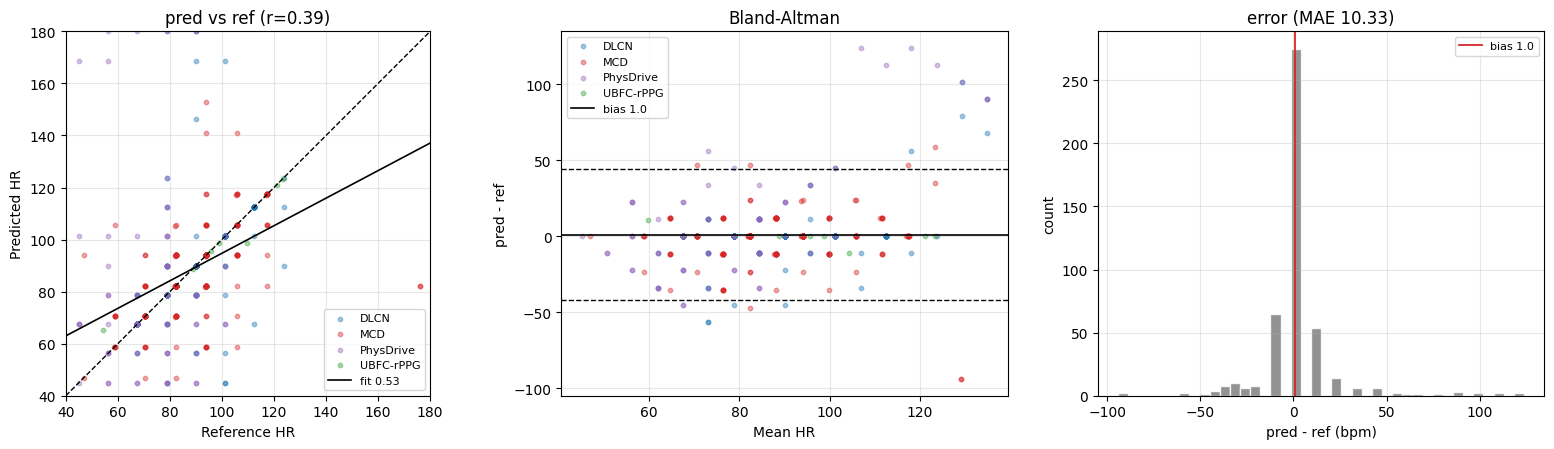

In [8]:
import matplotlib.pyplot as plt

@torch.no_grad()
def collect_predictions(model, loader):
    rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = rm_forward(model, frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    return pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])

def metrics_block(g):
    d = (g['hr_pred'] - g['hr_true']).values
    sd = d.std(ddof=1) if len(d) > 1 else np.nan
    return pd.Series(dict(n=len(g), MAE=np.abs(d).mean(), RMSE=np.sqrt((d ** 2).mean()), bias=d.mean(),
                          LoA_low=d.mean() - 1.96 * sd, LoA_high=d.mean() + 1.96 * sd,
                          Pearson_r=(np.corrcoef(g['hr_true'], g['hr_pred'])[0, 1] if len(g) > 2 else np.nan)))

colors = dict(MCD='tab:red', DLCN='tab:blue')
colors['UBFC-rPPG'] = 'tab:green'; colors['PhysDrive'] = 'tab:purple'
val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)

model = build_rhythmmamba().to(device)
model.load_state_dict(torch.load(ckpt, map_location=device)); model.eval()
pred_df = collect_predictions(model, val_loader)
summary = pred_df.groupby('dataset').apply(metrics_block, include_groups=False)
overall = metrics_block(pred_df); overall.name = 'ALL'
zs = [d for d in summary.index if d not in TRAIN_SET]
print('zero-shot datasets:', zs)
print(pd.concat([summary, overall.to_frame().T]).round(2).to_string())

diff = (pred_df.hr_pred - pred_df.hr_true).values
bias = diff.mean(); sd = diff.std(ddof=1)
r = np.corrcoef(pred_df.hr_true, pred_df.hr_pred)[0, 1]
lim = [40, 180]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
for ds, g in pred_df.groupby('dataset'):
    ax[0].scatter(g.hr_true, g.hr_pred, s=10, alpha=0.4, color=colors.get(ds, 'gray'), label=ds)
ax[0].plot(lim, lim, 'k--', lw=1)
sl, ic = np.polyfit(pred_df.hr_true, pred_df.hr_pred, 1)
ax[0].plot(np.array(lim), ic + sl * np.array(lim), 'k-', lw=1.2, label='fit ' + str(round(sl, 2)))
ax[0].set(xlim=lim, ylim=lim, xlabel='Reference HR', ylabel='Predicted HR', title='pred vs ref (r=' + str(round(r, 2)) + ')', aspect='equal')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
for ds, g in pred_df.groupby('dataset'):
    ax[1].scatter((g.hr_true + g.hr_pred) / 2, g.hr_pred - g.hr_true, s=10, alpha=0.4, color=colors.get(ds, 'gray'), label=ds)
ax[1].axhline(bias, color='k', lw=1.2, label='bias ' + str(round(bias, 1)))
ax[1].axhline(bias + 1.96 * sd, color='k', ls='--', lw=1); ax[1].axhline(bias - 1.96 * sd, color='k', ls='--', lw=1)
ax[1].set(xlabel='Mean HR', ylabel='pred - ref', title='Bland-Altman'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
ax[2].hist(diff, bins=40, color='tab:gray', alpha=0.85, edgecolor='white')
ax[2].axvline(bias, color='tab:red', lw=1.3, label='bias ' + str(round(bias, 1)))
ax[2].set(xlabel='pred - ref (bpm)', ylabel='count', title='error (MAE ' + str(round(np.abs(diff).mean(), 2)) + ')')
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
del model; gc.collect(); torch.cuda.empty_cache()

## 9. Discussion and conclusions

Applying the same loss swap to RhythmMamba did not reproduce the PhysNet/PhysFormer result. The shared MCD+DLCN+UBFC MAE finished at 7.50 (best, epoch 19), worse than the RhythmMamba v1 screen's 6.83, and DLCN - RhythmMamba's strongest set in v1 - regressed sharply from 2.32 to 6.56. MCD did improve (10.49 to 8.30) and UBFC-rPPG improved (4.19 to 3.12), but the net effect on the checkpoint metric was a regression.

The training dynamics explain part of it. Unlike the smooth PhysNet and PhysFormer runs, RhythmMamba's early epochs were unstable - the shared MAE rose to 44-57 through epochs 1-4 before recovering - and after reaching its epoch-19 best it oscillated between 7.5 and 11 for the remaining epochs rather than settling. The most plausible cause is a conflict between RhythmMamba's own internal frequency-domain feed-forward block and the external SNR frequency objective - two frequency-domain pressures on the same signal - compounded by RhythmMamba's known late-clicking convergence, which the sharper SNR gradient destabilises rather than sharpens.

The conclusion is that the SNR loss is architecture-dependent: a clear win for PhysNet (the primary model) and PhysFormer, and a net regression for RhythmMamba, which is better left with its native frequency-CE / neg-Pearson recipe if it is revisited. Combined with the other two runs, this confirms PhysNet v2 (shared 5.22, MCD 6.84, 0.77 M parameters) as both the smallest and the best model, and therefore the deployable HR backbone. PhysDrive again stayed high zero-shot (27.3 bpm), consistent with the in-vehicle gap being a data problem.